# Part 3: NLP and Sequence Modeling Mini Project
**Dataset:** Customer Support Text Classification  
**Task:** Sentiment Analysis (Negative / Neutral / Positive)  
**Pipeline:** Preprocessing → Vectorization → Baseline Models → Sequence Architecture → Reflection

In [9]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

os.makedirs('results', exist_ok=True)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [10]:
from google.colab import files
uploaded = files.upload()  # Upload your CSV here
df = pd.read_csv('customer_support_text_classification.csv')

Saving customer_support_text_classification.csv to customer_support_text_classification (1).csv


In [11]:
df = pd.read_csv('customer_support_text_classification.csv')

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Total Records  : {len(df)}')
print(f'Columns        : {list(df.columns)}')
print(f'Target Labels  : {df["sentiment_label"].unique().tolist()}')
print()
print('Class Distribution:')
print(df['sentiment_label'].value_counts())
print()
print(f'Avg Text Length (chars): {df["customer_message"].str.len().mean():.1f}')
print(f'Avg Word Count         : {df["word_count"].mean():.1f}')
print(f'Min / Max Word Count   : {df["word_count"].min()} / {df["word_count"].max()}')
print()
print('Sample Records (one per class):')
for label in df['sentiment_label'].unique():
    sample = df[df['sentiment_label'] == label].iloc[0]
    print(f'  [{label.upper()}] {sample["customer_message"]}')

DATASET OVERVIEW
Total Records  : 1500
Columns        : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']
Target Labels  : ['neutral', 'positive', 'negative']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Avg Text Length (chars): 72.8
Avg Word Count         : 12.7
Min / Max Word Count   : 7 / 26

Sample Records (one per class):
  [NEUTRAL] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  [POSITIVE] The refund process was fast and convenient. I appreciate the quick response.
  [NEGATIVE] My refund is still pending and this experience is frustrating. My ticket number is 33927.


In [12]:
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'he','him','his','she','her','hers','it','its','they','them','their',
    'what','which','who','is','am','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','could','should','may',
    'might','shall','can','need','dare','ought','used','a','an','the','and',
    'but','or','nor','for','so','yet','both','either','neither','not','only',
    'own','same','than','too','very','just','because','as','until','while',
    'of','at','by','for','with','about','against','between','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','then','once',
    'here','there','when','where','why','how','all','each','every',
    'some','any','no','that','this','these','those','s','t','don',
    'please','number','ticket','my','me','the','it','will'
])

def preprocess(text):
    """Full NLP preprocessing pipeline."""
    text = str(text).lower()                        # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # 2. Remove URLs
    text = re.sub(r'\b\d{4,}\b', '', text)          # 2. Remove long numbers (ticket IDs)
    text = re.sub(r'[^a-z\s]', '', text)            # 3. Remove special chars
    tokens = text.split()                           # 4. Tokenize
    tokens = [t for t in tokens                     # 5+6. Stopwords + short tokens
              if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['customer_message'].apply(preprocess)

print('Preprocessing Before / After Examples:')
print('-' * 60)
for _, row in df.sample(4, random_state=7).iterrows():
    print(f'ORIGINAL : {row["customer_message"]}')
    print(f'CLEANED  : {row["cleaned_text"]}')
    print()

Preprocessing Before / After Examples:
------------------------------------------------------------
ORIGINAL : Can you share the status of my insurance policy request? Please respond as soon as possible.
CLEANED  : share status insurance policy request respond soon possible

ORIGINAL : I am satisfied with the plan and would recommend it to others.
CLEANED  : satisfied plan recommend others

ORIGINAL : I want to cancel because the service quality is poor and unreliable. My ticket number is 18716.
CLEANED  : want cancel service quality poor unreliable

ORIGINAL : Please provide the steps to activate tracking. My ticket number is 63727.
CLEANED  : provide steps activate tracking



In [13]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment_label'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'], y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF (unigrams + bigrams)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train_text)
X_test_bow  = bow.transform(X_test_text)

print(f'\nTraining set size    : {len(X_train_text)} samples')
print(f'Test set size        : {len(X_test_text)} samples')
print(f'TF-IDF feature shape : {X_train_tfidf.shape}')
print(f'BoW feature shape    : {X_train_bow.shape}')

# Show top TF-IDF terms for a sample document
sample_idx = 0
sample_vec = X_train_tfidf[sample_idx]
feat_names = tfidf.get_feature_names_out()
top5 = np.argsort(sample_vec.toarray()[0])[-5:][::-1]
print(f'\nTop TF-IDF terms for training sample 0:')
for idx in top5:
    print(f'  "{feat_names[idx]}" → {sample_vec.toarray()[0][idx]:.4f}')

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Training set size    : 1200 samples
Test set size        : 300 samples
TF-IDF feature shape : (1200, 375)
BoW feature shape    : (1200, 142)

Top TF-IDF terms for training sample 0:
  "assigned respond" → 0.4339
  "assigned" → 0.3364
  "whether assigned" → 0.3364
  "confirm" → 0.3364
  "confirm whether" → 0.3364


In [14]:
results = {}

# ── Logistic Regression + TF-IDF ──────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred, average='macro')
results['LR + TF-IDF'] = {'accuracy': lr_acc, 'f1_macro': lr_f1}

print('=== Logistic Regression + TF-IDF ===')
print(f'Accuracy  : {lr_acc:.4f}')
print(f'F1 Macro  : {lr_f1:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=le.classes_))

# ── Naive Bayes + BoW ─────────────────────────────────────────────────────────
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
nb_pred = nb.predict(X_test_bow)

nb_acc = accuracy_score(y_test, nb_pred)
nb_f1  = f1_score(y_test, nb_pred, average='macro')
results['NB + BoW'] = {'accuracy': nb_acc, 'f1_macro': nb_f1}

print('=== Naive Bayes + Bag of Words ===')
print(f'Accuracy  : {nb_acc:.4f}')
print(f'F1 Macro  : {nb_f1:.4f}')
print()
print(classification_report(y_test, nb_pred, target_names=le.classes_))

# Save evaluation
eval_df = pd.DataFrame([{'Model': m, 'Accuracy': round(v['accuracy'],4),
                          'F1_Macro': round(v['f1_macro'],4)}
                         for m, v in results.items()])
eval_df.to_csv('results/model_evaluation.csv', index=False)
print('Saved → results/model_evaluation.csv')

=== Logistic Regression + TF-IDF ===
Accuracy  : 1.0000
F1 Macro  : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

=== Naive Bayes + Bag of Words ===
Accuracy  : 1.0000
F1 Macro  : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Saved → results/model_evaluation.csv


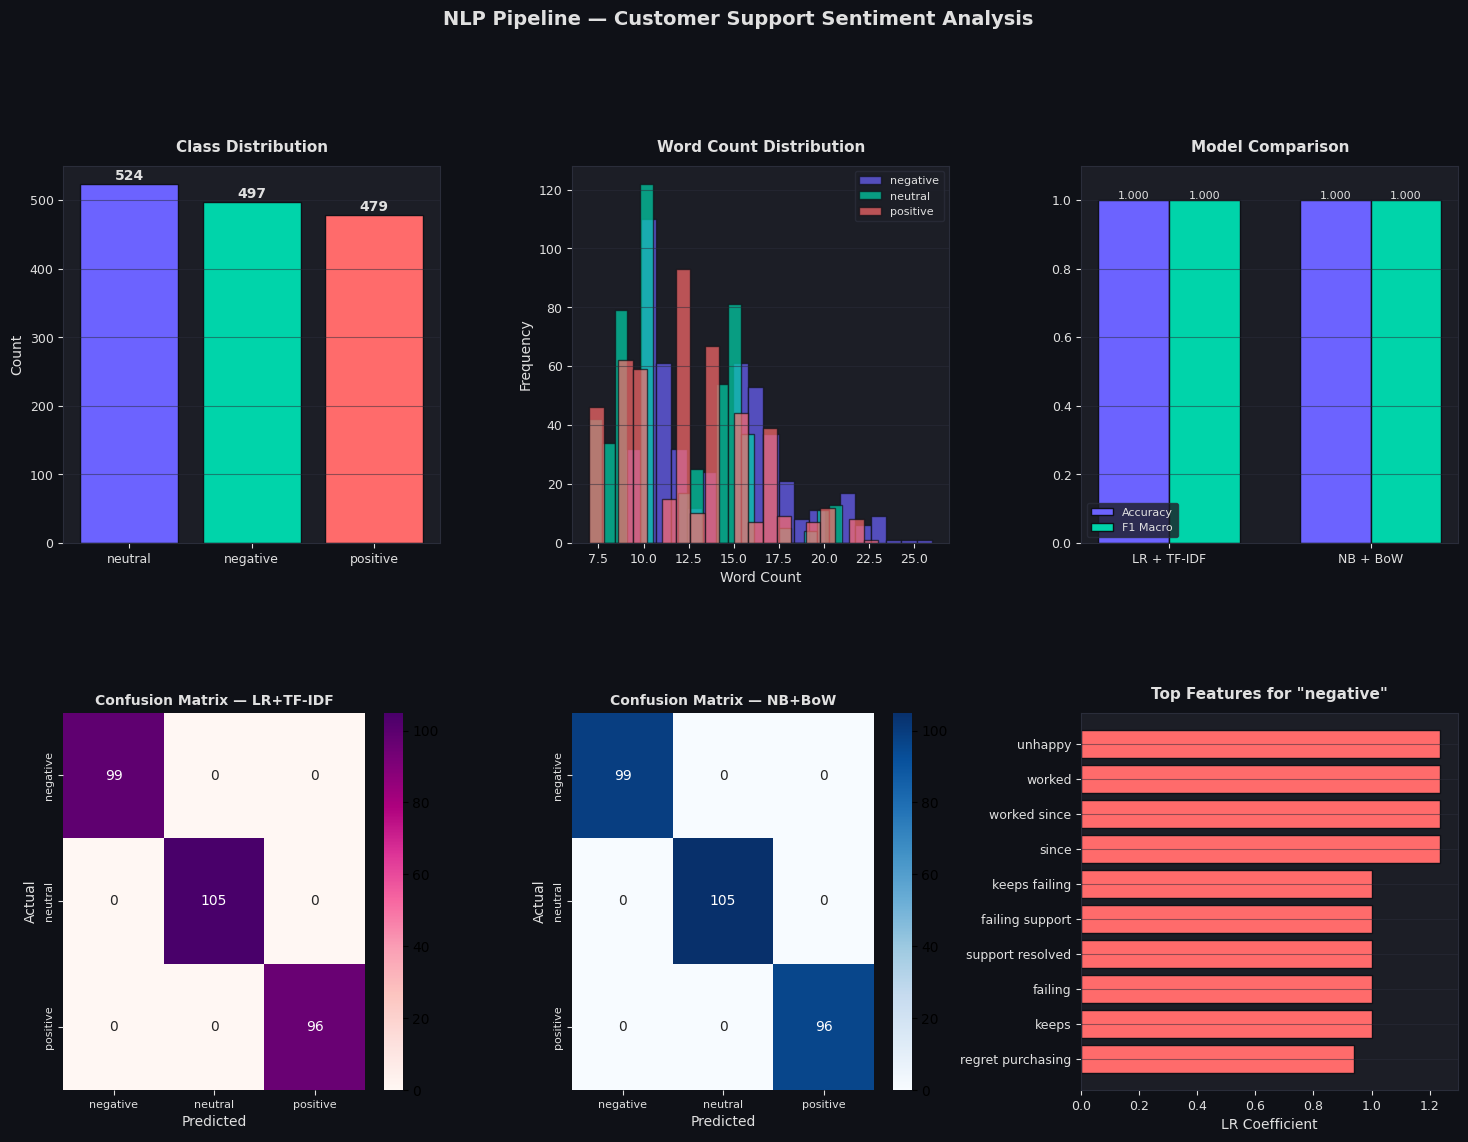

Saved → results/model_evaluation.png


In [15]:
# ── Visualisations ─────────────────────────────────────────────────────────────
DARK, PANEL = '#0f1117', '#1c1e26'
ACCENT = ['#6c63ff', '#00d4aa', '#ff6b6b']
TEXT_COL, GRID_COL = '#e0e0e0', '#2a2d3a'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
    ax.tick_params(colors=TEXT_COL, labelsize=9)
    ax.set_title(title, color=TEXT_COL, fontsize=11, fontweight='bold', pad=10)
    ax.xaxis.label.set_color(TEXT_COL); ax.yaxis.label.set_color(TEXT_COL)
    ax.grid(axis='y', color=GRID_COL, alpha=0.5)

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Class Distribution
ax1 = fig.add_subplot(gs[0, 0])
cc = df['sentiment_label'].value_counts()
bars = ax1.bar(cc.index, cc.values, color=ACCENT, edgecolor=DARK)
for bar, v in zip(bars, cc.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+6, str(v),
             ha='center', color=TEXT_COL, fontsize=10, fontweight='bold')
style_ax(ax1, 'Class Distribution'); ax1.set_ylabel('Count')

# Word Count Distribution
ax2 = fig.add_subplot(gs[0, 1])
for label, color in zip(le.classes_, ACCENT):
    ax2.hist(df[df['sentiment_label']==label]['word_count'], bins=20,
             alpha=0.7, label=label, color=color, edgecolor=DARK)
style_ax(ax2, 'Word Count Distribution')
ax2.set_xlabel('Word Count'); ax2.set_ylabel('Frequency')
ax2.legend(facecolor=PANEL, edgecolor=GRID_COL, labelcolor=TEXT_COL, fontsize=8)

# Model Comparison
ax3 = fig.add_subplot(gs[0, 2])
mn = list(results.keys())
accs = [results[m]['accuracy'] for m in mn]
f1s  = [results[m]['f1_macro'] for m in mn]
x = np.arange(len(mn)); w = 0.35
b1 = ax3.bar(x - w/2, accs, w, label='Accuracy', color=ACCENT[0], edgecolor=DARK)
b2 = ax3.bar(x + w/2, f1s,  w, label='F1 Macro', color=ACCENT[1], edgecolor=DARK)
for bar in list(b1)+list(b2):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{bar.get_height():.3f}', ha='center', color=TEXT_COL, fontsize=8)
ax3.set_xticks(x); ax3.set_xticklabels(mn, fontsize=8, color=TEXT_COL)
ax3.set_ylim(0, 1.1)
ax3.legend(facecolor=PANEL, edgecolor=GRID_COL, labelcolor=TEXT_COL, fontsize=8)
style_ax(ax3, 'Model Comparison')

# Confusion Matrix LR
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='RdPu',
            ax=ax4, xticklabels=le.classes_, yticklabels=le.classes_)
ax4.set_facecolor(PANEL); ax4.tick_params(colors=TEXT_COL, labelsize=8)
ax4.set_title('Confusion Matrix — LR+TF-IDF', color=TEXT_COL, fontsize=10, fontweight='bold')
ax4.set_xlabel('Predicted', color=TEXT_COL); ax4.set_ylabel('Actual', color=TEXT_COL)

# Confusion Matrix NB
ax5 = fig.add_subplot(gs[1, 1])
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues',
            ax=ax5, xticklabels=le.classes_, yticklabels=le.classes_)
ax5.set_facecolor(PANEL); ax5.tick_params(colors=TEXT_COL, labelsize=8)
ax5.set_title('Confusion Matrix — NB+BoW', color=TEXT_COL, fontsize=10, fontweight='bold')
ax5.set_xlabel('Predicted', color=TEXT_COL); ax5.set_ylabel('Actual', color=TEXT_COL)

# Top Features
ax6 = fig.add_subplot(gs[1, 2])
feat_names = np.array(tfidf.get_feature_names_out())
coef = lr.coef_[0]
top_idx = np.argsort(coef)[-10:]
ax6.barh(feat_names[top_idx], coef[top_idx],
         color=[ACCENT[2] if c > 0 else ACCENT[1] for c in coef[top_idx]], edgecolor=DARK)
style_ax(ax6, f'Top Features for "{le.classes_[0]}"')
ax6.set_xlabel('LR Coefficient')
ax6.axvline(0, color=TEXT_COL, linewidth=0.5)

fig.suptitle('NLP Pipeline — Customer Support Sentiment Analysis',
             color=TEXT_COL, fontsize=14, fontweight='bold', y=1.01)
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()
print('Saved → results/model_evaluation.png')

In [16]:
# ── Sample Predictions ─────────────────────────────────────────────────────────
test_texts = X_test_text.tolist()
with open('results/sample_predictions.txt', 'w') as f:
    f.write('SAMPLE PREDICTIONS — Logistic Regression + TF-IDF\n')
    f.write('=' * 60 + '\n\n')
    for i in range(min(10, len(test_texts))):
        true_label = le.inverse_transform([y_test[i]])[0]
        pred_label = le.inverse_transform([lr_pred[i]])[0]
        status = 'CORRECT' if true_label == pred_label else 'WRONG'
        f.write(f'[{status}]\n')
        f.write(f'  Text     : {test_texts[i][:80]}\n')
        f.write(f'  Actual   : {true_label}\n')
        f.write(f'  Predicted: {pred_label}\n\n')
print('Saved → results/sample_predictions.txt')

# Show in notebook
for i in range(5):
    true_label = le.inverse_transform([y_test[i]])[0]
    pred_label = le.inverse_transform([lr_pred[i]])[0]
    status = 'CORRECT' if true_label == pred_label else 'WRONG'
    print(f'[{status}] "{test_texts[i][:60]}..." | Actual: {true_label} | Pred: {pred_label}')

Saved → results/sample_predictions.txt
[CORRECT] "like new payment easy use..." | Actual: positive | Pred: positive
[CORRECT] "great service clear communication support team..." | Actual: positive | Pred: positive
[CORRECT] "refund still pending experience frustrating..." | Actual: negative | Pred: negative
[CORRECT] "app crashes whenever try use analytics..." | Actual: negative | Pred: negative
[CORRECT] "response team helpful professional..." | Actual: positive | Pred: positive


In [17]:
# Conceptual architecture display (without TensorFlow/Keras dependency)
architecture = [
    ('Input',            'raw text sequences',          'variable length strings'),
    ('Tokenizer',        'integer sequences (padded)',  'output shape: (batch, 50)'),
    ('Embedding',        'dense vector lookup table',   'output shape: (batch, 50, 128)'),
    ('SpatialDropout1D', 'feature-map dropout p=0.20',  'output shape: (batch, 50, 128)'),
    ('Bidirectional LSTM','128 units, returns last h',  'output shape: (batch, 256)'),
    ('Dense (ReLU)',     '64 hidden units',             'output shape: (batch, 64)'),
    ('Dropout',         'p=0.30',                       'output shape: (batch, 64)'),
    ('Dense (Softmax)', '3 output units',               'output shape: (batch, 3)'),
]

print(f'{"Layer":<22} {"Configuration":<30} {"Output Info"}')
print('-' * 75)
for layer, config, output in architecture:
    print(f'{layer:<22} {config:<30} {output}')

print()
print('Loss Function : Sparse Categorical Cross-Entropy')
print('Optimizer     : Adam (learning_rate=1e-3)')
print('Metric        : Accuracy, F1 Macro')
print('Epochs        : 15  (with early stopping, patience=3)')
print('Batch Size    : 32')

Layer                  Configuration                  Output Info
---------------------------------------------------------------------------
Input                  raw text sequences             variable length strings
Tokenizer              integer sequences (padded)     output shape: (batch, 50)
Embedding              dense vector lookup table      output shape: (batch, 50, 128)
SpatialDropout1D       feature-map dropout p=0.20     output shape: (batch, 50, 128)
Bidirectional LSTM     128 units, returns last h      output shape: (batch, 256)
Dense (ReLU)           64 hidden units                output shape: (batch, 64)
Dropout                p=0.30                         output shape: (batch, 64)
Dense (Softmax)        3 output units                 output shape: (batch, 3)

Loss Function : Sparse Categorical Cross-Entropy
Optimizer     : Adam (learning_rate=1e-3)
Metric        : Accuracy, F1 Macro
Epochs        : 15  (with early stopping, patience=3)
Batch Size    : 32
